# 03 — Baseline vs TabEBM(single) vs TabEBM(ensemble+VP-SGLD top-N)

nb 02 가 저장한 `sweep_top.json` 의 top-N VP-SGLD config 를 baseline + TabEBM single 과 비교.

### 설정 수
- `baseline` : 합성 없음
- `tabebm_single` : `TabEBM().generate(train, ...)`
- `vp_sgld[i]` (i = 0..N-1) : nb 02 의 top-N 각 config

### 주의 (데이터 누출)
저장된 ensemble 은 전체 데이터로 fit 되어 test split 을 surrogate 로 봤음.
공정 비교는 per-split refit 필요 (future work). 현재 MVP.

## 0. Setup — imports & classifier 공통 설정


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys, json, warnings, time, datetime as _dt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
warnings.filterwarnings('ignore')
os.chdir('/home/work/JooKyung/TabEBM')
sys.path.insert(0, 'experiments'); sys.path.insert(0, 'src')

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

from tabebm.TabEBM import TabEBM
from tabebm.vp_sgld import vp_sgld_from_ensemble

pd.set_option('display.width', 220); pd.set_option('display.precision', 3)

# 공통 설정
CLASSIFIERS     = ['knn', 'lr', 'rf', 'xgboost', 'mlp']
SEED, N_SPLITS  = 42, 10
N_SYN_PER_CLASS = 500
GPUS            = [0, 1, 2, 3]

def make_clf(name, seed=0):
    if name == 'knn':     return KNeighborsClassifier(n_jobs=-1)
    if name == 'lr':      return LogisticRegression(max_iter=1000, n_jobs=-1, random_state=seed)
    if name == 'rf':      return RandomForestClassifier(n_jobs=-1, random_state=seed)
    if name == 'xgboost': return xgb.XGBClassifier(n_jobs=-1, eval_metric='logloss', use_label_encoder=False, random_state=seed)
    if name == 'mlp':     return MLPClassifier(max_iter=300, random_state=seed)
    raise ValueError(name)

print('imports OK')


imports OK


## 1. 사용 가능한 ENSEMBLE 목록

`experiments/ebms/*_EBM/` 전부 나열. 아래 cell 실행하면 각 ensemble 의 methods / K / α 요약 출력.


In [2]:
EBMS_ROOT = Path('experiments/ebms')
print(f'{"name":<55} {"methods":<28} {"K":<4} {"α_range":<22}')
print('-' * 115)
for p in sorted(EBMS_ROOT.iterdir()):
    if not p.is_dir() or not p.name.endswith('_EBM'): continue
    c0 = p / 'c0'
    if not (c0 / 'meta.json').exists(): continue
    meta = json.loads((c0 / 'meta.json').read_text())
    K = meta.get('n_ebms', '?')
    methods = meta.get('methods_list', [])
    alphas = []
    for k in range(int(K) if isinstance(K, (int,str)) and str(K).isdigit() else 0):
        cfg_p = c0 / f'ebm_{k}' / 'config.json'
        if cfg_p.exists():
            a = json.loads(cfg_p.read_text()).get('method_distance', {}).get('neg_distance')
            if a is not None: alphas.append(a)
    arange = f'{min(alphas):.2f}..{max(alphas):.2f}' if alphas else '-'
    print(f'{p.name:<55} {str(methods):<28} {str(K):<4} {arange:<22}')


name                                                    methods                      K    α_range               
-------------------------------------------------------------------------------------------------------------------
20260415_184742_CornerNoise-Distance-NumFakeCorners_EBM ['CornerNoise', 'Distance', 'NumFakeCorners'] 10   3.73..27.88           
20260415_190012_CornerNoise-Distance-NumFakeCorners_EBM ['CornerNoise', 'Distance', 'NumFakeCorners'] 10   3.73..27.88           
20260415_200422_Distance_EBM                            ['Distance']                 10   3.73..29.29           
20260415_203146_Subsample_EBM                           ['Subsample']                10   -                     
20260415_204431_Subsample_EBM                           ['Subsample']                10   -                     
20260415_205240_Subsample-Distance_EBM                  ['Subsample', 'Distance']    10   3.45..8.40            
20260415_205627_Subsample-Distance_EBM                  ['S

## 2. ENSEMBLE 선택

위 목록 중 하나를 아래 `ENSEMBLE_ROOT` 에 붙여넣기.


In [3]:
ENSEMBLE_ROOT = Path('experiments/ebms/20260415_214026_Distance_EBM')    # ← 원하는 ensemble 이름으로 변경
assert (ENSEMBLE_ROOT / 'c0' / 'meta.json').exists(), f'not found: {ENSEMBLE_ROOT}'
print(f'ENSEMBLE_ROOT = {ENSEMBLE_ROOT}')


ENSEMBLE_ROOT = experiments/ebms/20260415_214026_Distance_EBM


## 2.5 선택한 ENSEMBLE 의 학습 설정 확인 + override

이 ensemble 이 어떤 설정으로 fit 됐는지 자동 로드.
다르게 돌리고 싶으면 아래 값 수정 (per-split refit 시에만 적용 — nb 03.1 용).

In [4]:
# --- 앙상블 학습 설정 자동 로드 ---
_meta_path = ENSEMBLE_ROOT / 'meta.json'
_ens_meta = json.loads(_meta_path.read_text()) if _meta_path.exists() else {}

# 멤버 config 에서 method/corner 정보 추출
_member0_cfg_path = ENSEMBLE_ROOT / 'c0' / 'ebm_0' / 'config.json'
_member0_cfg = json.loads(_member0_cfg_path.read_text()) if _member0_cfg_path.exists() else {}

# 자동 감지
_methods_detected = _ens_meta.get('methods', _ens_meta.get('methods_list', []))
_K_detected = _ens_meta.get('n_ebms', '?')
_has_subsample = 'method_subsample' in _member0_cfg
_has_distance = 'method_distance' in _member0_cfg
_corner_seed = _member0_cfg.get('corner_seed')
_member_seed = _member0_cfg.get('seed')
_shared_corners_detected = (_corner_seed != _member_seed) if _corner_seed is not None else '?'
# shared_corners=True 면 corner_seed == base_seed (member_seed 와 다름)
# shared_corners=False 면 corner_seed == member_seed
# corner_seed 없으면 (구 ensemble) → seed+k 로 corner 뽑았으므로 shared=False 추정
_shared_corners_detected = not (_corner_seed == _member_seed) if _corner_seed is not None else False  # 구 ensemble: per-member corner (shared=False)

# alpha 범위
_alphas = []
for k in range(int(_K_detected) if str(_K_detected).isdigit() else 0):
    _p = ENSEMBLE_ROOT / 'c0' / f'ebm_{k}' / 'config.json'
    if _p.exists():
        _c = json.loads(_p.read_text())
        _a = _c.get('method_distance', {}).get('neg_distance')
        if _a is not None: _alphas.append(_a)

print(f'=== 이 ensemble 의 학습 설정 (자동 감지) ===')
print(f'  methods:        {_methods_detected}')
print(f'  K (멤버 수):     {_K_detected}')
_cs_note = '' if _corner_seed is not None else '  (corner_seed 없는 구 ensemble → per-member 추정)'
print(f'  shared_corners: {_shared_corners_detected}{_cs_note}')
print(f'  subsample:      {_has_subsample}  '
       f'(ratio={_member0_cfg.get("method_subsample", {}).get("ratio", "-")})')
print(f'  distance:       {_has_distance}  '
       f'(α range: {min(_alphas):.2f}..{max(_alphas):.2f} 중 {len(_alphas)} 멤버)' if _alphas else '  distance:       no')
print()

# --- override 가능한 변수들 (기본 = 감지된 값) ---
# nb 03 에서는 pre-fit ensemble 을 그대로 사용하므로 이 값들은 '참조용'.
# per-split refit (nb 03.1) 할 때는 이 값들로 새 ensemble 설정.
ENS_METHODS         = _methods_detected
ENS_K               = int(_K_detected) if str(_K_detected).isdigit() else 10
ENS_SHARED_CORNERS  = _shared_corners_detected if isinstance(_shared_corners_detected, bool) else True
ENS_METHOD_PARAMS   = {}    # 비어있으면 기본값 사용

print(f'현재 사용할 설정 (override 가능):')
print(f'  ENS_METHODS:        {ENS_METHODS}')
print(f'  ENS_K:              {ENS_K}')
print(f'  ENS_SHARED_CORNERS: {ENS_SHARED_CORNERS}')
print(f'  ENS_METHOD_PARAMS:  {ENS_METHOD_PARAMS}')
print(f'\n(값 바꾸려면 위 변수 수정 후 이 셀 재실행)')


=== 이 ensemble 의 학습 설정 (자동 감지) ===
  methods:        ['Distance']
  K (멤버 수):     10
  shared_corners: False  (corner_seed 없는 구 ensemble → per-member 추정)
  subsample:      False  (ratio=-)
  distance:       True  (α range: 2.00..2.00 중 10 멤버)

현재 사용할 설정 (override 가능):
  ENS_METHODS:        ['Distance']
  ENS_K:              10
  ENS_SHARED_CORNERS: False
  ENS_METHOD_PARAMS:  {}

(값 바꾸려면 위 변수 수정 후 이 셀 재실행)


## 3. 이 ensemble 의 사용 가능한 SWEEP 목록

두 종류:
- **(S) SESSION** — nb 02.2 가 만든 `comparisons/sessions/<ts>_<tag>/`
- **(L) LEGACY** — nb 02 sweep 의 `sweeps/<ts>_<tag>/` (구 방식)


In [5]:
print(f'=== (S) SESSION sweeps   under  {ENSEMBLE_ROOT / "comparisons" / "sessions"} ===')
sessions_root = ENSEMBLE_ROOT / 'comparisons' / 'sessions'
if sessions_root.exists():
    for s in sorted(sessions_root.iterdir()):
        if s.is_dir():
            n_folders = sum(1 for p in (s/'sweeps').iterdir() if p.is_dir()) if (s/'sweeps').exists() else 0
            print(f'  {s.name:<55}  ({n_folders} sweep folders)')
else:
    print('  (no sessions yet — nb 02.2 를 돌리면 생김)')
print()
print(f'=== (L) LEGACY sweeps   under  {ENSEMBLE_ROOT / "sweeps"} ===')
legacy_root = ENSEMBLE_ROOT / 'sweeps'
if legacy_root.exists():
    for s in sorted(legacy_root.iterdir()):
        if s.is_dir():
            has_top = (s / 'sweep_top.json').exists()
            print(f'  {s.name:<55}  sweep_top.json: {"있음" if has_top else "없음"}')


=== (S) SESSION sweeps   under  experiments/ebms/20260415_214026_Distance_EBM/comparisons/sessions ===
  20260416_191851_all_axes_baseline                        (29 sweep folders)
  20260416_212804_smoke_test                               (3 sweep folders)
  20260416_213022_user_test_4tasks                         (2 sweep folders)
  20260416_213939_all_axes_baseline                        (29 sweep folders)
  20260417_160451_all_axes_baseline                        (19 sweep folders)
  20260417_165505_all_axes_baseline                        (21 sweep folders)
  20260417_180630_all_axes_baseline                        (21 sweep folders)
  20260417_182036_all_axes_baseline                        (21 sweep folders)

=== (L) LEGACY sweeps   under  experiments/ebms/20260415_214026_Distance_EBM/sweeps ===
  20260416_003653_baseline_only                            sweep_top.json: 있음
  20260416_004213_baseline_only                            sweep_top.json: 있음
  20260416_011918_baseline_onl

## 4. SWEEP 선택

- SESSION 모드: `SESSION_DIR` 에 위 (S) 목록 중 하나의 **전체 경로** (또는 끝 이름) 지정
- LEGACY 모드: `SWEEP_DIR_OVERRIDE` 에 위 (L) 목록 중 하나 지정
- 둘 다 `None` 이면: nb 02 legacy 자동탐지 (`ENSEMBLE_ROOT/sweep_top.json` mirror)


In [6]:
# 둘 중 하나만 지정 (다른 건 None 유지)
SESSION_DIR        = 'experiments/ebms/20260415_214026_Distance_EBM/comparisons/sessions/20260417_165505_all_axes_baseline'   # 예: ENSEMBLE_ROOT / 'comparisons' / 'sessions' / '20260416_150000_all_axes_baseline'
SWEEP_DIR_OVERRIDE = None   # 예: ENSEMBLE_ROOT / 'sweeps' / '20260416_004213_baseline_only'

# 동시 지정 금지
assert not (SESSION_DIR and SWEEP_DIR_OVERRIDE), 'SESSION_DIR 와 SWEEP_DIR_OVERRIDE 는 동시에 지정 불가'

if SESSION_DIR:
    if not isinstance(SESSION_DIR, Path): SESSION_DIR = Path(SESSION_DIR)
    assert (SESSION_DIR / 'sweeps').exists(), f'not a session: {SESSION_DIR}'
    SWEEP_SOURCE = SESSION_DIR
    MODE = 'SESSION'
elif SWEEP_DIR_OVERRIDE:
    if not isinstance(SWEEP_DIR_OVERRIDE, Path): SWEEP_DIR_OVERRIDE = Path(SWEEP_DIR_OVERRIDE)
    assert (SWEEP_DIR_OVERRIDE / 'sweep_top.json').exists(), f'no sweep_top.json: {SWEEP_DIR_OVERRIDE}'
    SWEEP_SOURCE = SWEEP_DIR_OVERRIDE
    MODE = 'LEGACY_EXPLICIT'
else:
    # auto — latest under ENSEMBLE_ROOT/sweeps/ or mirror at root
    legacy_sweeps = sorted((ENSEMBLE_ROOT / 'sweeps').iterdir() if (ENSEMBLE_ROOT/'sweeps').exists() else [])
    if legacy_sweeps:
        SWEEP_SOURCE = legacy_sweeps[-1]
        MODE = 'LEGACY_AUTO'
    else:
        mirror = ENSEMBLE_ROOT / 'sweep_top.json'
        assert mirror.exists(), 'no sweep source anywhere — nb 02 나 02.2 를 먼저 돌리세요'
        SWEEP_SOURCE = ENSEMBLE_ROOT
        MODE = 'LEGACY_MIRROR'

print(f'MODE         : {MODE}')
print(f'SWEEP_SOURCE : {SWEEP_SOURCE}')


MODE         : SESSION
SWEEP_SOURCE : experiments/ebms/20260415_214026_Distance_EBM/comparisons/sessions/20260417_165505_all_axes_baseline


## 5. 선택한 sweep 안의 **config 목록**

- SESSION: `sweeps/` 하위 폴더 이름들 (`baseline`, `beta__100.0`, …)
- LEGACY: `sweep_top.json` 의 Top-N configs 인덱스


In [7]:
if MODE == 'SESSION':
    sweeps_dir = SWEEP_SOURCE / 'sweeps'
    all_folders = sorted(p.name for p in sweeps_dir.iterdir() if p.is_dir())
    print(f'{len(all_folders)} config folders in SESSION:')
    for i, fn in enumerate(all_folders):
        rc = json.loads((sweeps_dir / fn / 'run_config.json').read_text())
        cfg = rc['cfg']
        tag = (f"β={cfg['beta']:<7g} η={cfg['eta']:<6g} τ={cfg['tau']:<5g} "
                f"σ0={cfg['sigma_start']:<5g} T={cfg['n_steps']:<4d} "
                f"ig_var={cfg['ignore_variance']}")
        print(f'  [{i:>2d}] {fn:<30}  {tag}')
    _AVAILABLE = all_folders
else:
    # LEGACY
    tp = SWEEP_SOURCE / 'sweep_top.json' if SWEEP_SOURCE.is_dir() else SWEEP_SOURCE
    if not tp.name.endswith('.json'):
        tp = SWEEP_SOURCE / 'sweep_top.json'
    sweep_top_preview = json.loads(tp.read_text())
    configs = sweep_top_preview['configs']
    print(f'{len(configs)} configs in LEGACY sweep_top.json:')
    for i, c in enumerate(configs):
        tag = 'baseline' if c['_axis'] == '_baseline' else f"{c['_axis']}={c['_value']}"
        sq = c.get('_sample_quality', float('nan'))
        print(f'  [{i:>2d}] {tag:<20}  sample_quality={sq:.4f}')
    _AVAILABLE = list(range(len(configs)))


21 config folders in SESSION:
  [ 0] baseline                        β=1e+06   η=0.05   τ=1     σ0=0.1   T=50   ig_var=False
  [ 1] beta__10000000                  β=1e+07   η=0.05   τ=1     σ0=0.1   T=50   ig_var=False
  [ 2] beta__100000000                 β=1e+08   η=0.05   τ=1     σ0=0.1   T=50   ig_var=False
  [ 3] beta__1000000000                β=1e+09   η=0.05   τ=1     σ0=0.1   T=50   ig_var=False
  [ 4] beta__10000000000               β=1e+10   η=0.05   τ=1     σ0=0.1   T=50   ig_var=False
  [ 5] beta__100000000000              β=1e+11   η=0.05   τ=1     σ0=0.1   T=50   ig_var=False
  [ 6] eta__0.01                       β=1e+06   η=0.01   τ=1     σ0=0.1   T=50   ig_var=False
  [ 7] eta__0.1                        β=1e+06   η=0.1    τ=1     σ0=0.1   T=50   ig_var=False
  [ 8] eta__0.2                        β=1e+06   η=0.2    τ=1     σ0=0.1   T=50   ig_var=False
  [ 9] eta__1.0                        β=1e+06   η=1      τ=1     σ0=0.1   T=50   ig_var=False
  [10] ignore_varian

## 6. 분석할 config 선택

- SESSION 모드: `VP_SELECT_FOLDERS` 에 folder 이름 리스트
- LEGACY 모드: `VP_SELECT` 에 인덱스 리스트
- `None` 이면 전부


In [8]:
VP_SELECT_FOLDERS = 'beta__10000000', 'beta__100000000', 'beta__1000000000', 'beta__10000000000', 'beta__100000000000'   # SESSION 모드 예: ['baseline', 'beta__100.0', 'sigma_start__2.0']
VP_SELECT         = None    # LEGACY 모드 예:  [0, 2, 4]

if MODE == 'SESSION':
    sweeps_dir = SWEEP_SOURCE / 'sweeps'
    selected = VP_SELECT_FOLDERS if VP_SELECT_FOLDERS is not None else _AVAILABLE
    missing = set(selected) - set(_AVAILABLE)
    assert not missing, f'존재하지 않는 folder: {missing}\navailable: {_AVAILABLE}'
    ALL_TOP_CONFIGS = []
    for fn in selected:
        rc = json.loads((sweeps_dir / fn / 'run_config.json').read_text())
        cfg = {**rc['cfg'],
                'kappa_sigma': None, 'kappa_mu': None, 'restart': False,
                'n_samples': N_SYN_PER_CLASS,
                '_axis':  fn.split('__', 1)[0] if '__' in fn else fn,
                '_value': fn.split('__', 1)[1] if '__' in fn else None,
                '_sample_quality': float('nan'),
                '_folder': fn}
        ALL_TOP_CONFIGS.append(cfg)
    sweep_top = {'rank_metric': 'session_order', 'sweep_out_dir': str(SWEEP_SOURCE),
                  'configs': ALL_TOP_CONFIGS}
    top_json_path = SWEEP_SOURCE
else:
    tp = SWEEP_SOURCE / 'sweep_top.json' if SWEEP_SOURCE.is_dir() else SWEEP_SOURCE
    if not tp.name.endswith('.json'):
        tp = SWEEP_SOURCE / 'sweep_top.json'
    sweep_top = json.loads(tp.read_text())
    all_cfgs = sweep_top['configs']
    if VP_SELECT is None:
        ALL_TOP_CONFIGS = all_cfgs
    else:
        ALL_TOP_CONFIGS = [all_cfgs[i] for i in VP_SELECT]
    top_json_path = tp

TOP_CONFIGS = list(ALL_TOP_CONFIGS)
VP_LABELS = []
for i, c in enumerate(TOP_CONFIGS):
    tag = 'baseline' if c.get('_axis') in (None, '_baseline') else f"{c['_axis']}={c['_value']}"
    VP_LABELS.append(f'vp[{i}]  ({tag})')

# 데이터 (cell 4 에서 쓰임) 로드
data = np.load(ENSEMBLE_ROOT / 'c0' / 'class_data.npz')
X_all = data['X_all']; y_all = data['y_all']
CLASSES = sorted(np.unique(y_all).tolist())

# NB03 output dir — sweep source 하위에 timestamped 분석 폴더
SWEEP_DIR = SWEEP_SOURCE if SWEEP_SOURCE.is_dir() and SWEEP_SOURCE.name != ENSEMBLE_ROOT.name else ENSEMBLE_ROOT
NB03_OUT_DIR = SWEEP_DIR / 'nb03' / _dt.datetime.now().strftime('%Y%m%d_%H%M%S')
NB03_OUT_DIR.mkdir(parents=True, exist_ok=True)
(NB03_OUT_DIR / 'config.json').write_text(json.dumps({
    'ensemble_root': str(ENSEMBLE_ROOT),
    'mode': MODE,
    'sweep_source': str(SWEEP_SOURCE),
    'VP_SELECT_FOLDERS': VP_SELECT_FOLDERS,
    'VP_SELECT': VP_SELECT,
    'selected_vp_labels': VP_LABELS,
    'CLASSIFIERS': CLASSIFIERS, 'N_SPLITS': N_SPLITS, 'SEED': SEED,
    'N_SYN_PER_CLASS': N_SYN_PER_CLASS,
}, indent=2, default=str))

print(f'Selected {len(TOP_CONFIGS)} configs:')
for lbl in VP_LABELS: print(f'  {lbl}')
print(f'\nNB03 outputs → {NB03_OUT_DIR}')


Selected 5 configs:
  vp[0]  (beta=10000000)
  vp[1]  (beta=100000000)
  vp[2]  (beta=1000000000)
  vp[3]  (beta=10000000000)
  vp[4]  (beta=100000000000)

NB03 outputs → experiments/ebms/20260415_214026_Distance_EBM/comparisons/sessions/20260417_165505_all_axes_baseline/nb03/20260417_202021


## 7. 데이터 + split

In [9]:
data = np.load(ENSEMBLE_ROOT / 'c0' / 'class_data.npz')
X_all = data['X_all']; y_all = data['y_all']
CLASSES = sorted(np.unique(y_all).tolist())
print(f'X_all {X_all.shape}, classes {CLASSES}, bincount {np.bincount(y_all).tolist()}')

n_test = min(len(X_all) // 2, 500)
splits = [next(StratifiedShuffleSplit(n_splits=1, test_size=n_test, random_state=SEED+i).split(X_all, y_all))
          for i in range(N_SPLITS)]
print(f'{N_SPLITS} splits, test size = {n_test}')

X_all (100, 9), classes [0, 1], bincount [53, 47]
10 splits, test size = 50


## 8. VP-SGLD 각 config 의 pool 생성 (병렬)

각 top config 마다 per-class 샘플 생성. config 수 × 2 (class) = GPU 에 분배.

In [10]:
# 저장된 trajectory 에서 최종 samples 로드 (SGLD 재실행 없음)
# SESSION 모드: sweeps/<folder>/diag_raw_c{c}.npz 의 trajectory[-1]
# LEGACY 모드: SGLD 재실행 (fallback)

vp_syn = {}
if TOP_CONFIGS:
    t0 = time.time()
    loaded_count = 0
    rerun_count = 0

    for ci, cfg in enumerate(TOP_CONFIGS):
        per_c = {}
        folder = cfg.get('_folder')   # SESSION 모드에서만 존재

        for c in CLASSES:
            loaded = False
            # SESSION 모드: 저장된 trajectory 에서 로드 시도
            if folder and SESSION_DIR is not None:
                npz_path = Path(SESSION_DIR) / 'sweeps' / folder / f'diag_raw_c{c}.npz'
                if npz_path.exists():
                    d = np.load(npz_path, allow_pickle=True)
                    if 'trajectory' in d.files:
                        per_c[c] = d['trajectory'][-1]   # (N, d) 최종 위치
                        loaded = True
                        loaded_count += 1

            # 로드 실패 → SGLD 재실행 (LEGACY fallback)
            if not loaded:
                gpu = GPUS[ci % len(GPUS)]
                samples = vp_sgld_from_ensemble(
                    ENSEMBLE_ROOT / f'c{c}',
                    n_samples=N_SYN_PER_CLASS, n_steps=cfg['n_steps'],
                    beta=cfg['beta'], eta=cfg['eta'], tau=cfg['tau'],
                    sigma_start=cfg['sigma_start'], auto_beta=cfg['auto_beta'],
                    restart=cfg.get('restart', False),
                    kappa_sigma=cfg.get('kappa_sigma'), kappa_mu=cfg.get('kappa_mu'),
                    ignore_variance=cfg.get('ignore_variance', False),
                    seed=SEED, gpu=gpu,
                ).numpy()
                per_c[c] = samples
                rerun_count += 1

        X_syn = np.vstack([per_c[c] for c in CLASSES])
        y_syn = np.concatenate([np.full(len(per_c[c]), c) for c in CLASSES]).astype(int)
        vp_syn[ci] = (X_syn, y_syn)
        print(f'  {VP_LABELS[ci]}: X={X_syn.shape}  bincount={np.bincount(y_syn).tolist()}')

    print(f'\nVP-SGLD pool 완료 ({time.time()-t0:.1f}s)  '
           f'loaded={loaded_count}  rerun={rerun_count}')
    if loaded_count > 0:
        print(f'  → {loaded_count} configs 는 저장된 trajectory 에서 즉시 로드 (SGLD 재실행 X)')
    if rerun_count > 0:
        print(f'  → {rerun_count} configs 는 trajectory 없어서 SGLD 재실행 (LEGACY fallback)')
else:
    print('TOP_CONFIGS 비어있음 — VP-SGLD pool 생성 스킵.')


  vp[0]  (beta=10000000): X=(1000, 9)  bincount=[500, 500]
  vp[1]  (beta=100000000): X=(1000, 9)  bincount=[500, 500]
  vp[2]  (beta=1000000000): X=(1000, 9)  bincount=[500, 500]
  vp[3]  (beta=10000000000): X=(1000, 9)  bincount=[500, 500]
  vp[4]  (beta=100000000000): X=(1000, 9)  bincount=[500, 500]

VP-SGLD pool 완료 (0.1s)  loaded=10  rerun=0
  → 10 configs 는 저장된 trajectory 에서 즉시 로드 (SGLD 재실행 X)


## 9. TabEBM single generate (split 마다)

In [11]:
def tabebm_single_generate(X_tr, y_tr, n_per_class=500, seed=0, gpu=0):
    te = TabEBM(device=f'cuda:{gpu}')
    res = te.generate(X_tr, y_tr, num_samples=n_per_class, seed=seed)
    classes = sorted(np.unique(y_tr))
    X_syn = np.vstack([res[f'class_{int(c)}'] for c in classes])
    y_syn = np.concatenate([np.full(len(res[f'class_{int(c)}']), c) for c in classes]).astype(int)
    return X_syn, y_syn

## 10. 평가 — baseline / tabebm_single / vp[0..N-1]

In [12]:
# VP config 이름: 'vp_' prefix + folder/axis 이름 (baseline 컬럼과 충돌 방지)
VP_SETTINGS = []
for _i, _cfg in enumerate(TOP_CONFIGS):
    _folder = _cfg.get('_folder')
    if _folder:
        VP_SETTINGS.append(f'vp_{_folder}')
    elif _cfg.get('_axis') in (None, '_baseline'):
        VP_SETTINGS.append('vp_baseline')
    else:
        VP_SETTINGS.append(f"vp_{_cfg['_axis']}={_cfg['_value']}")
SETTINGS = ['baseline', 'tabebm_single'] + VP_SETTINGS
print(f'SETTINGS: {SETTINGS}')

rows = []
for split_i, (tr, te) in enumerate(splits):
    X_tr, y_tr = X_all[tr], y_all[tr]
    X_te, y_te = X_all[te], y_all[te]
    X_syn_single, y_syn_single = tabebm_single_generate(
        X_tr, y_tr, n_per_class=N_SYN_PER_CLASS, seed=SEED+split_i, gpu=GPUS[0])

    for clf_name in CLASSIFIERS:
        row = {'split': split_i, 'classifier': clf_name}

        clf = make_clf(clf_name, seed=SEED+split_i); clf.fit(X_tr, y_tr)
        row['baseline'] = balanced_accuracy_score(y_te, clf.predict(X_te)) * 100

        clf = make_clf(clf_name, seed=SEED+split_i)
        clf.fit(np.vstack([X_tr, X_syn_single]), np.r_[y_tr, y_syn_single])
        row['tabebm_single'] = balanced_accuracy_score(y_te, clf.predict(X_te)) * 100

        for ci, (X_syn, y_syn) in vp_syn.items():
            clf = make_clf(clf_name, seed=SEED+split_i)
            clf.fit(np.vstack([X_tr, X_syn]), np.r_[y_tr, y_syn])
            row[VP_SETTINGS[ci]] = balanced_accuracy_score(y_te, clf.predict(X_te)) * 100

        rows.append(row)
    print(f'split {split_i+1}/{N_SPLITS}')

df = pd.DataFrame(rows)
df.to_csv(NB03_OUT_DIR / 'splits_raw.csv', index=False)
print(f'  saved: {NB03_OUT_DIR / "splits_raw.csv"}  ({len(df)} rows)')
df.head()


SETTINGS: ['baseline', 'tabebm_single', 'vp_beta__10000000', 'vp_beta__100000000', 'vp_beta__1000000000', 'vp_beta__10000000000', 'vp_beta__100000000000']
split 1/10
split 2/10
split 3/10
split 4/10
split 5/10
split 6/10
split 7/10
split 8/10
split 9/10
split 10/10
  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/sessions/20260417_165505_all_axes_baseline/nb03/20260417_202021/splits_raw.csv  (50 rows)


,split,classifier,baseline,tabebm_single,vp_beta__10000000,vp_beta__100000000,vp_beta__1000000000,vp_beta__10000000000,vp_beta__100000000000
0,0,knn,84.541,93.800,100.000,100.000,100.000,100.000,100.000
1,0,lr,74.316,74.316,91.948,91.948,91.948,91.948,91.948
2,0,rf,85.749,85.427,100.000,100.000,100.000,100.000,100.000
3,0,xgboost,81.723,90.097,100.000,100.000,100.000,100.000,100.000
4,0,mlp,93.800,93.800,97.826,97.826,97.826,97.826,97.826


## 11. Mean ± std 결과 + delta_pp

In [12]:
mean_df = df.groupby('classifier')[SETTINGS].mean()
std_df  = df.groupby('classifier')[SETTINGS].std()
print('Mean balanced acc (%):'); print(mean_df)
print('\nStd (%):'); print(std_df)
mean_df.to_csv(NB03_OUT_DIR / 'mean_bacc.csv')
std_df.to_csv(NB03_OUT_DIR / 'std_bacc.csv')
print(f'  saved: mean_bacc.csv, std_bacc.csv')


Mean balanced acc (%):
            baseline  tabebm_single   vp[0]   vp[1]   vp[2]   vp[3]
classifier                                                         
knn           82.309         88.785  82.309  82.309  88.073  98.730
lr            79.563         83.461  75.357  74.061  73.677  90.980
mlp           87.780         90.331  61.138  50.217  84.330  99.130
rf            86.858         88.702  86.330  84.656  90.560  98.359
xgboost       84.431         88.745  84.351  86.137  90.647  98.359

Std (%):
            baseline  tabebm_single   vp[0]  vp[1]  vp[2]  vp[3]
classifier                                                      
knn            5.025          3.201   5.025  5.025  4.452  1.096
lr             6.735          5.189   5.918  6.670  6.278  1.740
mlp            4.894          4.053  10.594  0.687  3.090  1.123
rf             3.566          3.086   3.956  5.075  2.397  0.875
xgboost        5.415          3.765   2.937  3.790  3.189  0.875
  saved: mean_bacc.csv, std_bacc.csv

In [13]:
# delta vs baseline
delta = df.copy()
for s in [c for c in SETTINGS if c != 'baseline']:
    delta[f'Δ_{s}'] = delta[s] - delta['baseline']
delta_cols = [f'Δ_{s}' for s in SETTINGS if s != 'baseline']
delta_agg = delta.groupby('classifier')[delta_cols].agg(['mean','std'])
delta_agg.to_csv(NB03_OUT_DIR / 'delta_vs_baseline.csv')
print(f'  saved: delta_vs_baseline.csv')
delta_agg


  saved: delta_vs_baseline.csv


Δ_tabebm_single        Δ_vp[0]         Δ_vp[1]        Δ_vp[2]        Δ_vp[3]       
                      mean    std    mean     std    mean    std    mean    std    mean    std
classifier                                                                                    
knn                  6.476  6.958   0.000   0.000   0.000  0.000   5.764  6.654  16.421  5.440
lr                   3.897  4.465  -4.206   2.850  -5.502  3.675  -5.887  3.739  11.417  6.627
mlp                  2.551  2.875 -26.641  13.472 -37.562  4.734  -3.450  5.505  11.351  5.152
rf                   1.844  3.326  -0.528   3.033  -2.202  3.383   3.702  2.890  11.502  3.665
xgboost              4.314  4.357  -0.080   5.030   1.706  5.971   6.215  5.823  13.928  5.587

## 12. Bar chart — per classifier × setting

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/sessions/20260416_191851_all_axes_baseline/nb03/20260417_163645/bar_bacc.png


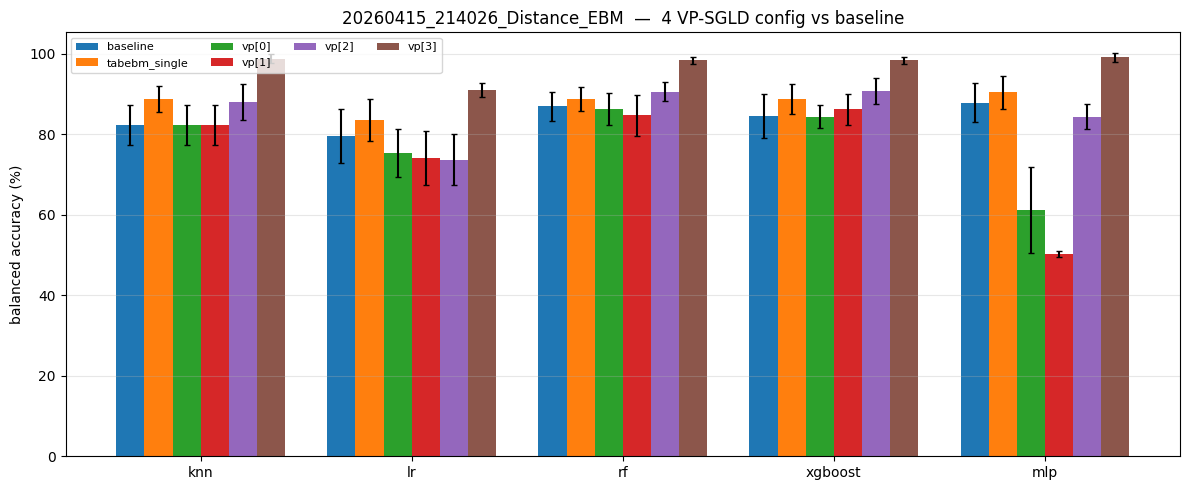

In [14]:
n_set = len(SETTINGS)
fig, ax = plt.subplots(figsize=(max(8, 1.2*len(CLASSIFIERS)*n_set/3), 5))
x = np.arange(len(CLASSIFIERS))
w = 0.8 / n_set
for i, s in enumerate(SETTINGS):
    means = [mean_df.loc[c, s] for c in CLASSIFIERS]
    stds  = [std_df.loc[c, s]  for c in CLASSIFIERS]
    ax.bar(x + (i - (n_set-1)/2) * w, means, w, yerr=stds, label=s, capsize=2)
ax.set_xticks(x); ax.set_xticklabels(CLASSIFIERS)
ax.set_ylabel('balanced accuracy (%)')
ax.set_title(f'{ENSEMBLE_ROOT.name}  —  {len(TOP_CONFIGS)} VP-SGLD config vs baseline')
ax.legend(ncol=min(n_set,4), fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig_path = NB03_OUT_DIR / 'bar_bacc.png'
fig.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f'  saved: {fig_path}')
plt.show()


## 13. Top config 요약 + 가장 robust 한 VP setting

어느 VP config 가 어떤 classifier 에서 baseline 을 얼마나 이겼는지.

In [ ]:
# top VP settings 의 config 요약 + classifier 평균 delta
summary = []
for ci, cfg in enumerate(TOP_CONFIGS):
    col = f'Δ_{VP_SETTINGS[ci]}'
    avg_delta = float(delta[col].mean())
    robust_count = int((delta.groupby('classifier')[col].mean() > 0).sum())
    summary.append({
        'vp_idx': ci,
        'axis': cfg['_axis'], 'value': cfg['_value'],
        'sample_quality_nb02': cfg['_sample_quality'],
        'mean_Δ_pp': avg_delta,
        'classifiers_beating_baseline': f'{robust_count}/{len(CLASSIFIERS)}',
    })
summary_df = pd.DataFrame(summary).sort_values('mean_Δ_pp', ascending=False)
summary_df.to_csv(NB03_OUT_DIR / 'vp_config_summary.csv', index=False)

print(f'\n=== {NB03_OUT_DIR} ===')
for p in sorted(NB03_OUT_DIR.iterdir()):
    print(f'  {p.name:<28}  {p.stat().st_size:>8} bytes')

summary_df
